# Smartphone Activity Recognition from Anonymized IMU Features

This notebook trains and evaluates activity-recognition models on a public-safe feature table derived from processed smartphone IMU recordings. Raw sensor traces, original participant names, collection timestamps, ZIP files, and local paths are not included in this repository.

## Workflow

1. Load the anonymized feature dataset.
2. Check the activity and participant distribution.
3. Run a stratified holdout benchmark.
4. Run leave-one-participant-out validation to test user-independent generalization.
5. Inspect the strongest model's most important features.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from har_features import (
    evaluate_holdout,
    evaluate_leave_one_participant_out,
    load_feature_dataset,
    make_models,
    split_features,
    summarize_lopo,
)

DATA_PATH = PROJECT_ROOT / "data" / "anonymized_har_features.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 20)
print("Using data/anonymized_har_features.csv")

Using data/anonymized_har_features.csv


In [2]:
dataset = load_feature_dataset(DATA_PATH)
print(f"Rows: {dataset.shape[0]:,}")
print(f"Columns: {dataset.shape[1]:,}")
print("Participants:", sorted(dataset["participant"].unique()))
print("Activities:", sorted(dataset["activity"].unique()))

dataset.head()

Rows: 398
Columns: 116
Participants: ['participant_01', 'participant_02', 'participant_03']
Activities: ['run', 'sit', 'stairs', 'stand', 'walk']


,participant,activity,trial_id,acc_corr_xy,acc_corr_xz,acc_corr_yz,acc_mag_energy,acc_mag_fft_energy,acc_mag_iqr,acc_mag_max,...,gyro_z_energy,gyro_z_fft_energy,gyro_z_iqr,gyro_z_max,gyro_z_mean,gyro_z_median,gyro_z_min,gyro_z_rms,gyro_z_std,n_samples
0,participant_01,run,participant_01_run_001,0.337639,0.352015,-0.326435,119.207418,111101.930013,12.550765,73.970002,...,5.368179,5003.165774,2.812735,8.629556,-0.032723,-0.070623,-7.305901,2.317164,2.316933,934.0
1,participant_01,run,participant_01_run_002,0.190765,0.207260,-0.396629,120.804200,117663.414975,13.257279,72.840810,...,5.318439,5180.165325,2.539473,8.507704,0.019289,0.014037,-8.812702,2.306255,2.306174,975.0
2,participant_01,run,participant_01_run_003,0.197161,0.248858,-0.383340,118.679440,114169.744266,12.488687,66.026340,...,5.996956,5769.078353,2.646976,7.951870,-0.013668,-0.027830,-7.578089,2.448907,2.448868,963.0
3,participant_01,run,participant_01_run_004,0.248552,0.247898,-0.406870,119.110102,124113.262535,13.488995,62.841222,...,4.395253,4579.870334,2.323860,7.182051,-0.015770,0.044241,-6.887649,2.096545,2.096486,1044.0
4,participant_01,run,participant_01_run_005,0.199980,0.197062,-0.387358,154.001836,149690.522810,14.783793,84.875238,...,6.229419,6055.020454,2.978575,8.731421,0.013400,-0.079906,-9.823797,2.495916,2.495880,974.0


In [3]:
# Privacy/safety checks for public release.
object_columns = dataset.select_dtypes(include="object")
windows_path_pattern = r"[A-Za-z]:\\"
has_windows_path = object_columns.apply(lambda col: col.astype(str).str.contains(windows_path_pattern, regex=True)).any().any()
assert not has_windows_path, "Potential absolute Windows path found in object columns."
assert dataset["participant"].str.match(r"participant_\d{2}").all()
print("Safety checks passed: participant IDs are anonymized and no absolute Windows paths were found in object columns.")

Safety checks passed: participant IDs are anonymized and no absolute Windows paths were found in object columns.


In [4]:
activity_counts = dataset["activity"].value_counts().sort_index()
participant_counts = pd.crosstab(dataset["participant"], dataset["activity"])

display(activity_counts.rename("trials_per_activity").to_frame())
display(participant_counts)

,trials_per_activity
activity,
run,82
sit,80
stairs,73
stand,87
walk,76


activity,run,sit,stairs,stand,walk
participant,,,,,
participant_01,30,30,29,31,30
participant_02,22,20,15,26,16
participant_03,30,30,29,30,30


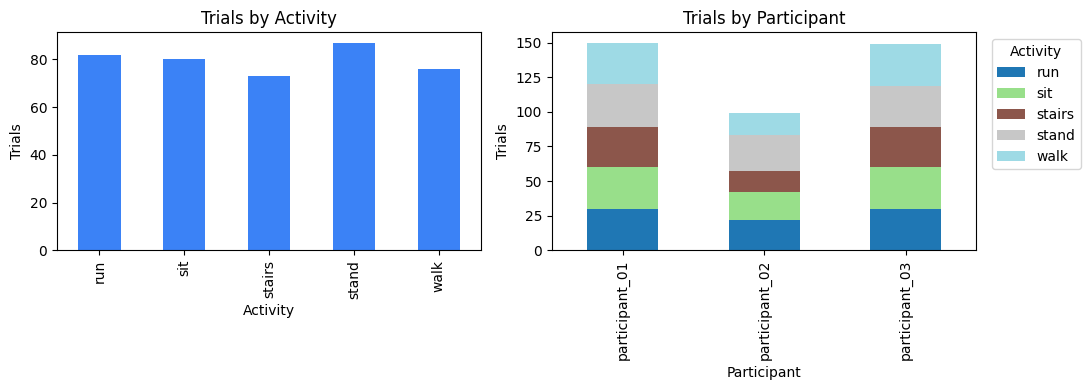

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
activity_counts.plot(kind="bar", ax=axes[0], color="#3b82f6")
axes[0].set_title("Trials by Activity")
axes[0].set_xlabel("Activity")
axes[0].set_ylabel("Trials")

participant_counts.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Trials by Participant")
axes[1].set_xlabel("Participant")
axes[1].set_ylabel("Trials")
axes[1].legend(title="Activity", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "har_class_balance.png", dpi=160, bbox_inches="tight")
plt.show()

## Stratified Holdout Benchmark

This split is useful as a quick model sanity check. It mixes participants between train and test, so it is easier than deployment on a completely unseen user.

In [6]:
holdout_results = evaluate_holdout(dataset)
holdout_results.round(3)

,model,accuracy,balanced_accuracy,macro_f1
4,random_forest,0.96,0.962,0.962
1,knn,0.93,0.935,0.933
3,decision_tree,0.92,0.924,0.922
0,logistic_regression,0.91,0.914,0.914
2,gaussian_nb,0.81,0.817,0.819


## Leave-One-Participant-Out Validation

This is the stricter evaluation. Each fold holds out one anonymized participant, trains on the other participants, and tests on the held-out participant.

In [7]:
lopo_results = evaluate_leave_one_participant_out(dataset)
lopo_summary = summarize_lopo(lopo_results)

display(lopo_results.round(3))
display(lopo_summary.round(3))

,model,fold,held_out_participant,accuracy,balanced_accuracy,macro_f1
0,logistic_regression,1,participant_01,0.413,0.411,0.392
1,logistic_regression,2,participant_02,0.545,0.536,0.544
2,logistic_regression,3,participant_03,0.752,0.753,0.742
3,knn,1,participant_01,0.427,0.422,0.358
4,knn,2,participant_02,0.505,0.504,0.513
5,knn,3,participant_03,0.577,0.580,0.519
6,gaussian_nb,1,participant_01,0.247,0.247,0.176
7,gaussian_nb,2,participant_02,0.495,0.488,0.466
8,gaussian_nb,3,participant_03,0.664,0.663,0.591
9,decision_tree,1,participant_01,0.353,0.357,0.260


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
4,random_forest,0.627,0.156,0.628,0.157,0.594,0.157
3,logistic_regression,0.570,0.171,0.566,0.173,0.559,0.175
2,knn,0.503,0.075,0.502,0.079,0.463,0.091
0,decision_tree,0.475,0.161,0.486,0.154,0.407,0.196
1,gaussian_nb,0.469,0.210,0.466,0.208,0.411,0.213


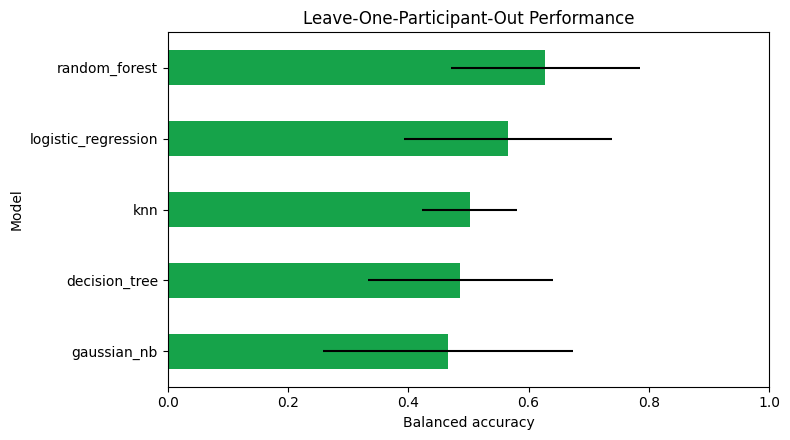

In [8]:
plot_df = lopo_summary.set_index("model").sort_values("balanced_accuracy_mean")
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df["balanced_accuracy_mean"].plot(kind="barh", xerr=plot_df["balanced_accuracy_std"], ax=ax, color="#16a34a")
ax.set_xlabel("Balanced accuracy")
ax.set_ylabel("Model")
ax.set_title("Leave-One-Participant-Out Performance")
ax.set_xlim(0, 1)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "har_lopo_results.png", dpi=160, bbox_inches="tight")
plt.show()

## Feature Importance

The random forest is used here for a simple feature-importance view. This is not a causal interpretation; it is a quick way to see which engineered IMU features were most useful to the fitted model.

,importance
acc_y_fft_energy,0.0433
acc_x_fft_energy,0.0411
acc_z_fft_energy,0.0350
acc_y_energy,0.0330
grav_z_fft_energy,0.0301
grav_y_rms,0.0283
grav_z_iqr,0.0282
grav_y_energy,0.0266
grav_z_energy,0.0255
acc_y_rms,0.0247


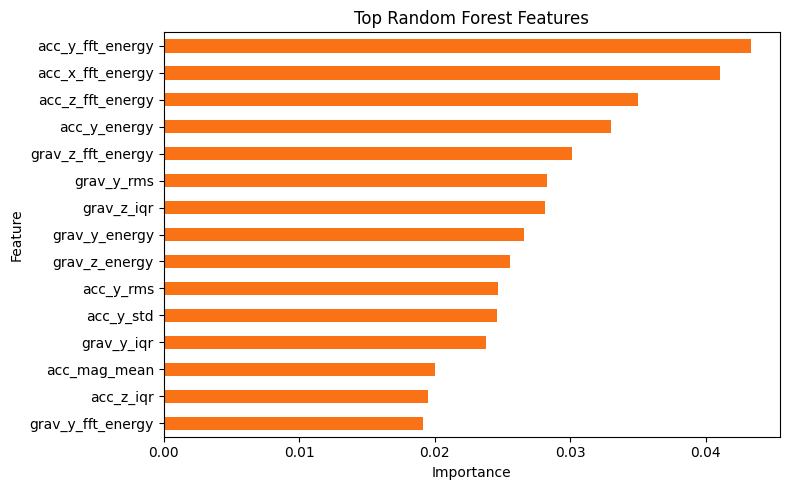

In [9]:
x, y, _ = split_features(dataset)
rf_model = make_models()["random_forest"]
rf_model.fit(x, y)
forest = rf_model.named_steps["randomforestclassifier"]
importances = pd.Series(forest.feature_importances_, index=x.columns).sort_values(ascending=False)

top_features = importances.head(15).rename("importance").to_frame()
display(top_features.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
top_features.sort_values("importance").plot(kind="barh", ax=ax, legend=False, color="#f97316")
ax.set_title("Top Random Forest Features")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "har_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

## Summary

The stratified holdout split confirms that the feature table is learnable. The leave-one-participant-out scores are lower, which is expected and more realistic for activity recognition across unseen users. The public repository intentionally uses derived anonymized features rather than raw participant recordings.